In [1]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import io

# 1. 模拟你的数据输入 (你可以替换成 pd.read_csv('your_file.csv'))
# data_str = """Sample,Anti_Dnd,Dnd,Anti_CRISPR,Cas,Anti_RM,RM,Anti_CBASS,CBASS,Anti_Thoeris,Thoeris,Anti_Retron,Retron,Anti_Pycsar,Pycsar,Anti_Gabija,Gabija
# Apis_37,1,0,1,1,0,1,1,1,1,1,1,1,0,0,0,0
# Apis_40,0,0,1,1,0,1,0,1,1,1,0,1,0,0,0,1
# Bee_haven,0,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1
# Bombus_1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
# Bombus_2,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1
# Bombus_3,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1
# ME_2020-07-24_15m,0,0,0,1,1,1,1,1,1,1,1,1,0,1,0,1
# ME_2020-07-24_23.5m,0,1,1,1,1,1,0,1,1,1,0,1,0,1,0,1
# ME_2020-07-24_5m,0,0,1,1,1,1,0,1,1,1,0,1,0,0,0,1
# ME_2020-08-05_15m,0,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1
# ME_2020-08-05_23.5m,1,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1
# ME_2020-08-25_15m,0,1,1,1,1,1,1,1,1,1,0,1,0,1,1,1
# ME_2020-08-25_23.5m,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1
# ME_2020-09-11_15m,0,1,1,1,1,1,1,1,1,1,0,1,0,1,0,1
# ME_2020-09-11_23.5m,0,0,0,1,1,1,0,1,1,1,0,1,0,1,0,1
# ME_2020-10-08_15m,0,1,1,1,1,1,0,1,1,1,0,1,0,1,0,0
# ME_2020-10-08_23.5m,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
# ME_2020-10-19_15m,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0
# ME_2020-10-19_23.5m,0,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0
# APC055_916,0,0,1,1,1,1,0,0,0,0,0,1,0,0,0,0
# APC055_917,0,0,0,1,1,1,0,1,1,1,0,0,0,0,0,0
# APC055_918,0,0,0,1,1,1,0,1,1,1,0,0,0,0,0,1
# APC055_919,0,0,0,1,1,1,0,1,0,0,0,0,0,1,0,0
# APC055_920,0,0,0,1,1,1,0,0,1,1,0,0,0,0,0,1
# APC055_921,0,1,1,1,1,1,0,1,1,0,0,1,0,0,0,0
# APC055_922,0,0,0,1,0,1,0,1,1,0,0,1,0,0,0,0
# APC055_923,0,0,1,1,1,1,0,1,1,0,0,1,0,0,0,1
# APC055_924,0,0,1,1,1,1,0,1,1,1,0,0,0,0,0,1
# APC055_925,0,0,0,1,1,1,0,0,0,1,0,1,0,0,0,1
# TARA_064_DCM,0,0,1,1,1,1,0,1,0,0,0,0,0,0,0,1
# TARA_064_SRF,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0
# TARA_065_DCM,0,0,0,1,1,1,0,0,1,1,0,0,0,0,0,0
# TARA_065_SRF,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
# TARA_066_DCM,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0"""

df = pd.read_csv(r"C:\Users\jingqing\Desktop\pair_sample_matrix.csv")

# 2. 定义你要检验的 8 个 Pair
# 注意你提到的：和 Anti_CRISPR 对应的是 Cas
pairs_to_test = [
    ("Dnd", "Anti_Dnd"),
    ("Cas", "Anti_CRISPR"),
    ("RM", "Anti_RM"),
    ("CBASS", "Anti_CBASS"),
    ("Thoeris", "Anti_Thoeris"),
    ("Retron", "Anti_Retron"),
    ("Pycsar", "Anti_Pycsar"),
    ("Gabija", "Anti_Gabija")
]

results = []

print("=== 共现性检验结果 (保持边缘总和固定的精确检验) ===\n")
print(f"{'Pair (DS vs ADS)':<25} | {'共现(1,1)':<10} | {'优势比(OR)':<10} | {'P-value (单侧)':<15} | {'结论'}")
print("-" * 80)

for ds, ads in pairs_to_test:
    # 确保列名在数据中存在
    if ds not in df.columns or ads not in df.columns:
        print(f"Warning: 列 {ds} 或 {ads} 不在数据中，跳过。")
        continue

    # 提取这两列
    col_ds = df[ds]
    col_ads = df[ads]

    # 构建 2x2 列联表
    #          ADS = 1    ADS = 0
    # DS = 1   count_11   count_10
    # DS = 0   count_01   count_00

    count_11 = np.sum((col_ds == 1) & (col_ads == 1))
    count_10 = np.sum((col_ds == 1) & (col_ads == 0))
    count_01 = np.sum((col_ds == 0) & (col_ads == 1))
    count_00 = np.sum((col_ds == 0) & (col_ads == 0))

    contingency_table = [[count_11, count_10],
                         [count_01, count_00]]

    # 使用 Fisher 精确检验 (本质上是保持边缘固定的完全置换检验)
    # alternative='greater' 意味着我们检验的是 "非随机组合的概率大于随机组合" (即正相关/共现倾向)
    oddsratio, p_value = fisher_exact(contingency_table, alternative='greater')

    # 判断结论
    if p_value < 0.05:
        conclusion = "显著共现 (非随机结合)"
    else:
        conclusion = "未发现显著共现"

    results.append({
        'Pair': f"{ds} - {ads}",
        'Co_occurrence': count_11,
        'Odds_Ratio': round(oddsratio, 4) if not np.isinf(oddsratio) else "Inf",
        'P_value': round(p_value, 5),
        'Conclusion': conclusion
    })

    print(f"{ds + ' vs ' + ads:<25} | {count_11:<10} | {round(oddsratio, 4) if not np.isinf(oddsratio) else 'Inf':<10} | {p_value:<15.5f} | {conclusion}")

# 如果你想保存结果为 CSV
# results_df = pd.DataFrame(results)
# results_df.to_csv("pair_cooccurrence_results.csv", index=False)

=== 共现性检验结果 (保持边缘总和固定的精确检验) ===

Pair (DS vs ADS)          | 共现(1,1)    | 优势比(OR)    | P-value (单侧)    | 结论
--------------------------------------------------------------------------------
Dnd vs Anti_Dnd           | 1          | 0.9825     | 0.69709         | 未发现显著共现
Cas vs Anti_CRISPR        | 22         | 1.3469     | 0.38608         | 未发现显著共现
RM vs Anti_RM             | 49         | 2.45       | 0.16493         | 未发现显著共现
CBASS vs Anti_CBASS       | 9          | 0.311      | 0.99388         | 未发现显著共现
Thoeris vs Anti_Thoeris   | 23         | 1.0455     | 0.55138         | 未发现显著共现
Retron vs Anti_Retron     | 3          | Inf        | 0.14517         | 未发现显著共现
Pycsar vs Anti_Pycsar     | 0          | 0.0        | 1.00000         | 未发现显著共现
Gabija vs Anti_Gabija     | 1          | Inf        | 0.55696         | 未发现显著共现


=== Co-occurrence Test Results (Fisher's Exact Test) ===

Pair (DS vs ADS)          | Co-occur(1,1)   | Odds Ratio(OR)  | P-value(1-sided)     | Conclusion
----------------------------------------------------------------------------------------------------
Dnd vs Anti_Dnd           | 1               | 0.9825          | 0.69709              | Not Significant
Cas vs Anti_CRISPR        | 22              | 1.3469          | 0.38608              | Not Significant
RM vs Anti_RM             | 49              | 2.45            | 0.16493              | Not Significant
CBASS vs Anti_CBASS       | 9               | 0.311           | 0.99388              | Not Significant
Thoeris vs Anti_Thoeris   | 23              | 1.0455          | 0.55138              | Not Significant
Retron vs Anti_Retron     | 3               | Inf             | 0.14517              | Not Significant
Pycsar vs Anti_Pycsar     | 0               | 0.0             | 1.00000              | Not Significant
Gabija vs Anti_Gabija 

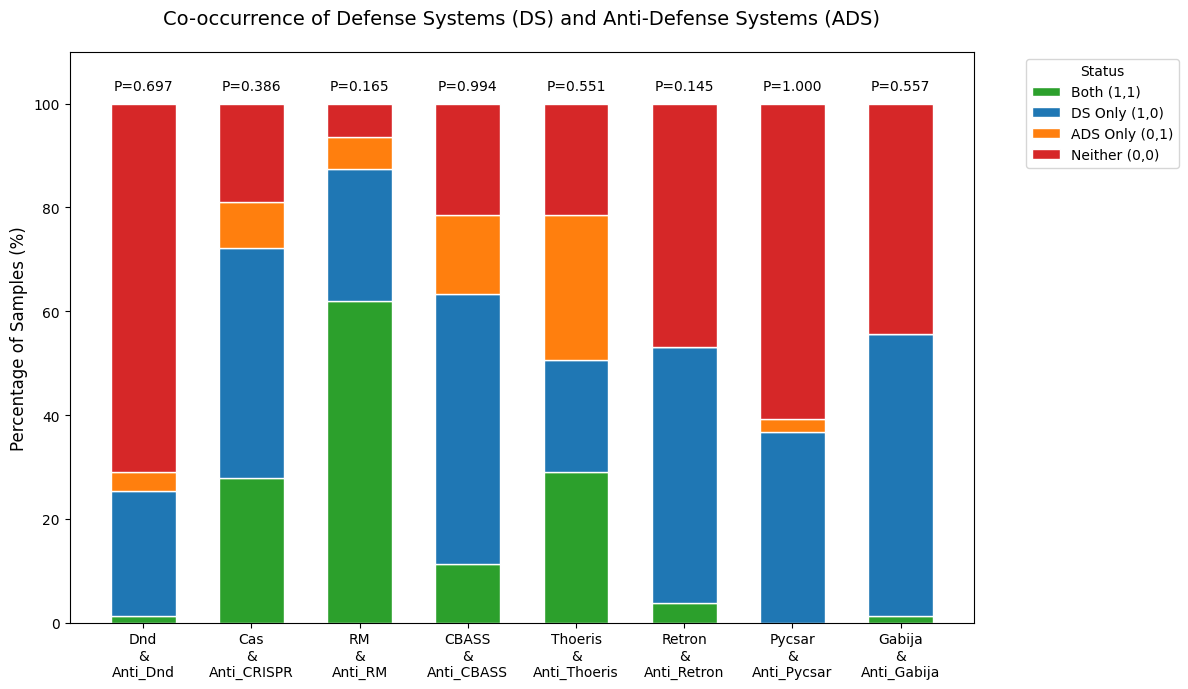

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Data Loading and Analysis
# ==========================================
df = pd.read_csv(r"C:\Users\jingqing\Desktop\pair_sample_matrix.csv")

pairs_to_test = [
    ("Dnd", "Anti_Dnd"),
    ("Cas", "Anti_CRISPR"),
    ("RM", "Anti_RM"),
    ("CBASS", "Anti_CBASS"),
    ("Thoeris", "Anti_Thoeris"),
    ("Retron", "Anti_Retron"),
    ("Pycsar", "Anti_Pycsar"),
    ("Gabija", "Anti_Gabija")
]

results = []
# Dataset for plotting
plot_data = []

print("=== Co-occurrence Test Results (Fisher's Exact Test) ===\n")
print(f"{'Pair (DS vs ADS)':<25} | {'Co-occur(1,1)':<15} | {'Odds Ratio(OR)':<15} | {'P-value(1-sided)':<20} | {'Conclusion'}")
print("-" * 100)

for ds, ads in pairs_to_test:
    if ds not in df.columns or ads not in df.columns:
        print(f"Warning: Columns {ds} or {ads} not found in data, skipping.")
        continue

    col_ds = df[ds]
    col_ads = df[ads]

    count_11 = np.sum((col_ds == 1) & (col_ads == 1))
    count_10 = np.sum((col_ds == 1) & (col_ads == 0))
    count_01 = np.sum((col_ds == 0) & (col_ads == 1))
    count_00 = np.sum((col_ds == 0) & (col_ads == 0))

    contingency_table = [[count_11, count_10],
                         [count_01, count_00]]

    oddsratio, p_value = fisher_exact(contingency_table, alternative='greater')

    if p_value < 0.05:
        conclusion = "Significant Co-occurrence"
    else:
        conclusion = "Not Significant"

    results.append({
        'Pair': f"{ds} & {ads}",
        'Co_occurrence': count_11,
        'Odds_Ratio': round(oddsratio, 4) if not np.isinf(oddsratio) else "Inf",
        'P_value': round(p_value, 5),
        'Conclusion': conclusion
    })

    # Record plot data (converted to percentages for easier comparison)
    total_samples = len(col_ds)
    plot_data.append({
        'Pair': f"{ds}\n&\n{ads}",
        'Both (1,1)': (count_11 / total_samples) * 100,
        'DS Only (1,0)': (count_10 / total_samples) * 100,
        'ADS Only (0,1)': (count_01 / total_samples) * 100,
        'Neither (0,0)': (count_00 / total_samples) * 100,
        'P_value': p_value
    })

    print(f"{ds + ' vs ' + ads:<25} | {count_11:<15} | {round(oddsratio, 4) if not np.isinf(oddsratio) else 'Inf':<15} | {p_value:<20.5f} | {conclusion}")

# ==========================================
# 2. Plotting (Stacked Bar Chart)
# ==========================================
plot_df = pd.DataFrame(plot_data)

# Extract category colors
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Green, Blue, Orange, Red
categories = ['Both (1,1)', 'DS Only (1,0)', 'ADS Only (0,1)', 'Neither (0,0)']

fig, ax = plt.subplots(figsize=(12, 7))

# Plot stacked bar chart
bottoms = np.zeros(len(plot_df))
for i, category in enumerate(categories):
    ax.bar(plot_df['Pair'], plot_df[category], bottom=bottoms, label=category, color=colors[i], edgecolor='white', width=0.6)
    bottoms += plot_df[category].values

# Add P-value annotations at the top of the chart
for i, row in plot_df.iterrows():
    p_val = row['P_value']
    # If significant, display in bold red with an asterisk
    if p_val < 0.05:
        p_text = f"P={p_val:.3f}*"
        weight = 'bold'
        color = 'red'
    else:
        p_text = f"P={p_val:.3f}"
        weight = 'normal'
        color = 'black'

    ax.text(i, 102, p_text, ha='center', va='bottom', fontsize=10, weight=weight, color=color)

# Format the chart
ax.set_ylabel('Percentage of Samples (%)', fontsize=12)
ax.set_title('Co-occurrence of Defense Systems (DS) and Anti-Defense Systems (ADS)', fontsize=14, pad=20)
ax.set_ylim(0, 110) # Leave space for P-values

# Move the legend outside the chart
ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Automatically adjust layout to prevent clipping
plt.show()

# To save the plot:
# plt.savefig("pair_cooccurrence_plot.png", dpi=300, bbox_inches='tight')

# ### Visual Chart Interpretation:
# 1. **X-axis:** Displays the 8 independent Pair combinations.
# 2. **Y-axis:** Represents the percentage of the total sample count (0% - 100%).
# 3. **Color Blocks:**
#    * **Green (Both 1,1):** The larger this proportion is in the bar, the more frequently they appear together.
#    * **Blue / Orange:** Represents the presence of only the Defense System (DS) or only the Anti-Defense System (ADS).
#    * **Red (Neither 0,0):** Neither system was detected in the sample.
# 4. **Top P-value Annotation:** Directly above each bar, the P-value calculated by Fisher's Exact Test is displayed. If $P < 0.05$, the value is **bolded, red, and marked with an asterisk**, allowing you to identify pairs with significant biological co-occurrence at a glance.

=== Permutation Test Results ===

Pair                       Observed    Expected      Fold     P-value
---------------------------------------------------------------------------
Dnd vs Anti_Dnd                   1        1.02      0.98     0.70263
Cas vs Anti_CRISPR               22       20.90      1.05     0.37846
RM vs Anti_RM                    49       47.16      1.04     0.16518
CBASS vs Anti_CBASS               9       13.30      0.68     0.99450
Thoeris vs Anti_Thoeris          23       22.77      1.01     0.55444
Retron vs Anti_Retron             3        1.59      1.89     0.14209
Pycsar vs Anti_Pycsar             0        0.74      0.00     1.00000
Gabija vs Anti_Gabija             1        0.56      1.80     0.55674


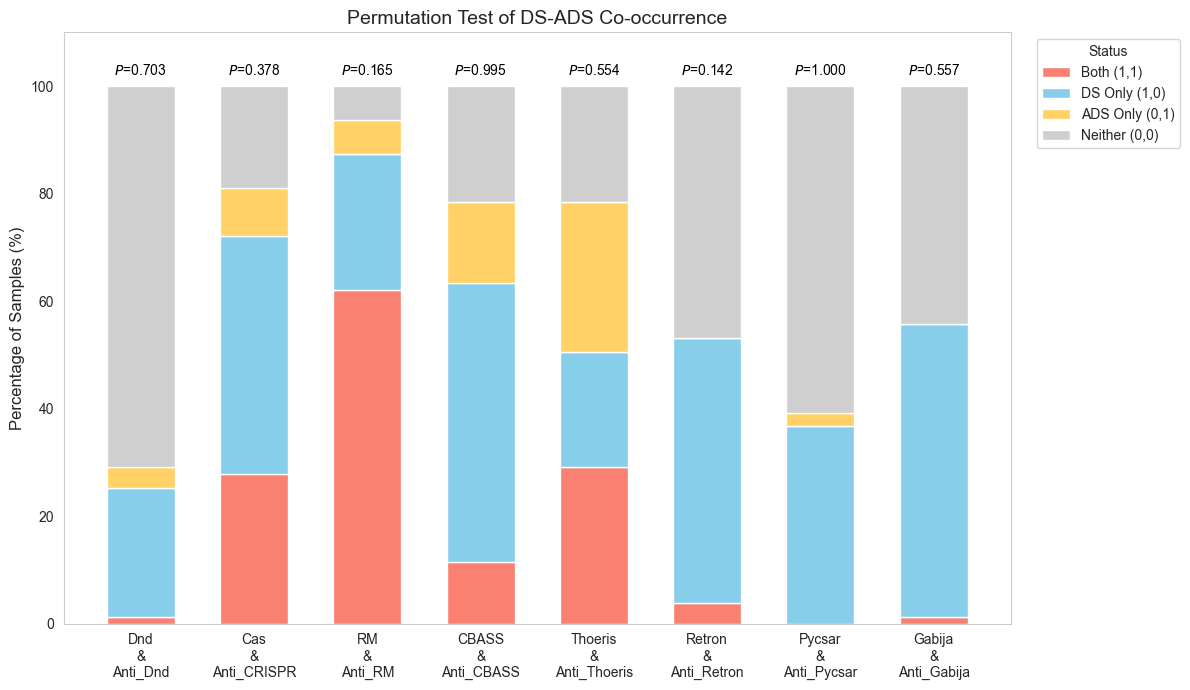

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters
# ==========================================
N_PERM = 10000
RANDOM_SEED = 42

# ==========================================
# Load Data
# ==========================================
df = pd.read_csv(r"C:\Users\jingqing\Desktop\pair_sample_matrix.csv")

pairs_to_test = [
    ("Dnd", "Anti_Dnd"),
    ("Cas", "Anti_CRISPR"),
    ("RM", "Anti_RM"),
    ("CBASS", "Anti_CBASS"),
    ("Thoeris", "Anti_Thoeris"),
    ("Retron", "Anti_Retron"),
    ("Pycsar", "Anti_Pycsar"),
    ("Gabija", "Anti_Gabija")
]

rng = np.random.default_rng(RANDOM_SEED)

results = []
plot_data = []

print("=== Permutation Test Results ===\n")

print(
    f"{'Pair':<25}"
    f"{'Observed':>10}"
    f"{'Expected':>12}"
    f"{'Fold':>10}"
    f"{'P-value':>12}"
)

print("-" * 75)

# ==========================================
# Permutation Analysis
# ==========================================

for ds, ads in pairs_to_test:

    if ds not in df.columns or ads not in df.columns:
        print(f"Missing column: {ds} or {ads}")
        continue

    ds_vec = df[ds].to_numpy()
    ads_vec = df[ads].to_numpy()

    # --------------------------------------
    # Observed overlap
    # --------------------------------------

    observed_overlap = np.sum((ds_vec == 1) & (ads_vec == 1))

    # --------------------------------------
    # Permutation
    # --------------------------------------

    perm_overlap = np.zeros(N_PERM)

    for i in range(N_PERM):

        shuffled_ads = rng.permutation(ads_vec)

        perm_overlap[i] = np.sum(
            (ds_vec == 1) &
            (shuffled_ads == 1)
        )

    expected_overlap = perm_overlap.mean()

    fold = observed_overlap / expected_overlap if expected_overlap > 0 else np.nan

    p_value = (
        np.sum(perm_overlap >= observed_overlap) + 1
    ) / (N_PERM + 1)

    if p_value < 0.05:
        conclusion = "Significant"
    else:
        conclusion = "Not Significant"

    print(
        f"{ds+' vs '+ads:<25}"
        f"{observed_overlap:>10}"
        f"{expected_overlap:>12.2f}"
        f"{fold:>10.2f}"
        f"{p_value:>12.5f}"
    )

    # --------------------------------------
    # Save results
    # --------------------------------------

    results.append({

        "Pair": f"{ds} & {ads}",

        "Observed_overlap": observed_overlap,

        "Expected_overlap": round(expected_overlap, 2),

        "Fold_enrichment": round(fold, 2),

        "Permutation_P": round(p_value, 5),

        "Conclusion": conclusion

    })

    # --------------------------------------
    # Plot data
    # --------------------------------------

    total = len(ds_vec)

    both = np.sum((ds_vec == 1) & (ads_vec == 1))
    ds_only = np.sum((ds_vec == 1) & (ads_vec == 0))
    ads_only = np.sum((ds_vec == 0) & (ads_vec == 1))
    neither = np.sum((ds_vec == 0) & (ads_vec == 0))

    plot_data.append({

        "Pair": f"{ds}\n&\n{ads}",

        "Both (1,1)": both / total * 100,

        "DS Only (1,0)": ds_only / total * 100,

        "ADS Only (0,1)": ads_only / total * 100,

        "Neither (0,0)": neither / total * 100,

        "P_value": p_value

    })

# ==========================================
# Save Result Table
# ==========================================

result_df = pd.DataFrame(results)

result_df.to_csv(
    "Permutation_results.csv",
    index=False
)

# ==========================================
# Plot
# ==========================================

plot_df = pd.DataFrame(plot_data)

colors = [
    "#FA8072",
    "#87CEEB",
    "#FFD166",
    "#CFCFCF"
]
categories = [
    "Both (1,1)",
    "DS Only (1,0)",
    "ADS Only (0,1)",
    "Neither (0,0)"
]

fig, ax = plt.subplots(figsize=(12,7))

bottom = np.zeros(len(plot_df))

for i, cat in enumerate(categories):

    ax.bar(
        plot_df["Pair"],
        plot_df[cat],
        bottom=bottom,
        color=colors[i],
        edgecolor="white",
        width=0.6,
        label=cat
    )

    bottom += plot_df[cat].values

# ------------------------------------------
# Add P-values
# ------------------------------------------

for i, row in plot_df.iterrows():

    if row["P_value"] < 0.05:

        txt = f"P={row['P_value']:.3f}*"

        color = "red"

        weight = "bold"

    else:

        txt = f"$P$={row['P_value']:.3f}"

        color = "black"

        weight = "normal"

    ax.text(
        i,
        102,
        txt,
        ha="center",
        fontsize=10,
        color=color,
        weight=weight
    )

# ------------------------------------------

ax.set_ylim(0,110)

ax.set_ylabel("Percentage of Samples (%)", fontsize=12)

ax.set_title(
    "Permutation Test of DS-ADS Co-occurrence",
    fontsize=14
)

ax.legend(
    title="Status",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
plt.grid(False)
plt.tight_layout()

plt.savefig('barchart.pdf')

plt.show()

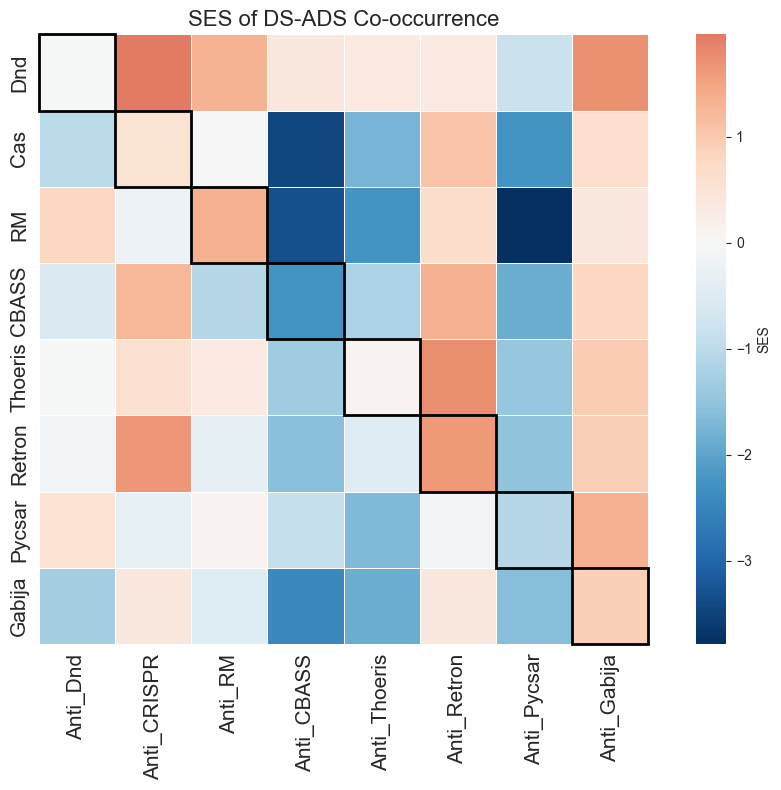

C:\Users\jingqing\AppData\Local\Temp\ipykernel_27872\2358843959.py:253: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_box = sns.boxplot(


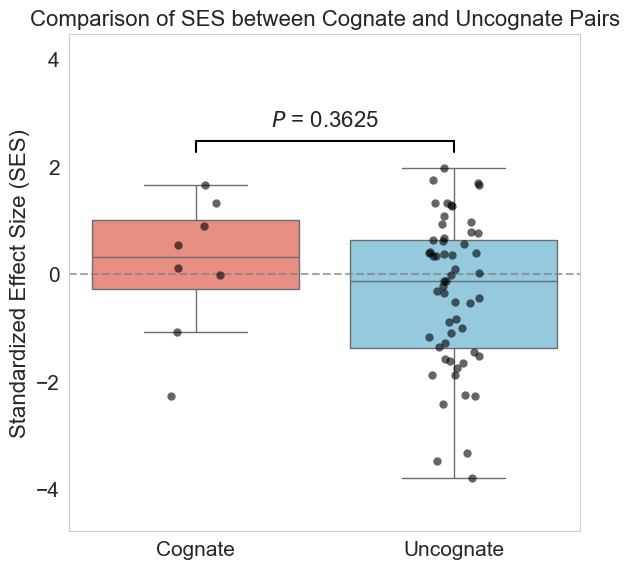


=== SES Group Comparison ===
Cognate pairs (n=8): Mean SES = 0.14, Median SES = 0.32
Uncognate pairs (n=56): Mean SES = -0.34, Median SES = -0.12
Mann-Whitney U Test P-value: 3.6249e-01


<Figure size 640x480 with 0 Axes>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
from statsmodels.stats.multitest import multipletests

# ====================================================
# Parameters
# ====================================================

N_PERM = 10000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

# ====================================================
# Read data
# ====================================================

df = pd.read_csv(r"C:\Users\jingqing\Desktop\pair_sample_matrix.csv")

DS_list = [
    "Dnd",
    "Cas",
    "RM",
    "CBASS",
    "Thoeris",
    "Retron",
    "Pycsar",
    "Gabija"
]

ADS_list = [
    "Anti_Dnd",
    "Anti_CRISPR",
    "Anti_RM",
    "Anti_CBASS",
    "Anti_Thoeris",
    "Anti_Retron",
    "Anti_Pycsar",
    "Anti_Gabija"
]

# ====================================================
# Result matrices
# ====================================================

SES_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)
P_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)
Expected_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)
Observed_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)
Fold_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)

# 保存所有P值用于FDR
all_p = []
pair_index = []

# ====================================================
# Permutation
# ====================================================

for ds in DS_list:
    if ds not in df.columns:
        print(f"Warning: {ds} not in dataframe.")
        continue
    ds_vec = df[ds].values

    for ads in ADS_list:
        if ads not in df.columns:
            print(f"Warning: {ads} not in dataframe.")
            continue
        ads_vec = df[ads].values

        observed = np.sum((ds_vec == 1) & (ads_vec == 1))

        perm_overlap = np.zeros(N_PERM)

        for i in range(N_PERM):
            shuffled = rng.permutation(ads_vec)
            perm_overlap[i] = np.sum(
                (ds_vec == 1) &
                (shuffled == 1)
            )

        expected = np.mean(perm_overlap)
        sd = np.std(perm_overlap, ddof=1)

        if sd == 0:
            ses = np.nan
        else:
            ses = (observed - expected) / sd

        # 计算真实观测值偏离理论期望值的绝对距离
        diff_obs = np.abs(observed - expected)

        # 计算所有 10000 次置换模拟值偏离理论期望值的绝对距离
        diff_perm = np.abs(perm_overlap - expected)

        # 双侧 P 值：统计“模拟偏离距离”大于或等于“观测偏离距离”的次数比例
        p = (np.sum(diff_perm >= diff_obs) + 1) / (N_PERM + 1)

        fold = observed / expected if expected > 0 else np.nan

        SES_matrix.loc[ds, ads] = ses
        P_matrix.loc[ds, ads] = p
        Expected_matrix.loc[ds, ads] = expected
        Observed_matrix.loc[ds, ads] = observed
        Fold_matrix.loc[ds, ads] = fold

        all_p.append(p)
        pair_index.append((ds, ads))
SES_matrix.to_csv(r"C:\Users\jingqing\Desktop\SES_matrix.csv")
# ====================================================
# FDR correction
# ====================================================

if len(all_p) > 0:
    reject, qvals, _, _ = multipletests(
        all_p,
        method="fdr_bh"
    )

    Q_matrix = pd.DataFrame(index=DS_list, columns=ADS_list, dtype=float)

    for (ds, ads), q in zip(pair_index, qvals):
        Q_matrix.loc[ds, ads] = q

# ====================================================
# Draw heatmap
# ====================================================

plt.figure(figsize=(10,8))

ax = sns.heatmap(
    SES_matrix.astype(float),
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={
        "label":"SES"
    }
)

# 获取颜色映射对象，用于判断背景深浅
cmap = ax.collections[0].cmap
norm = ax.collections[0].norm

# 添加显著性星号和对角线黑框
for i, ds in enumerate(DS_list):
    for j, ads in enumerate(ADS_list):
        # 1. 处理对角线黑框 (假设 DS 和 ADS 是对应的，即 i == j)
        if i == j:
            # 添加矩形框: xy是左下角坐标 (j, i)，width和height为1
            rect = patches.Rectangle(
                (j, i), 1, 1,
                fill=False,
                edgecolor='black',
                linewidth=2,
                clip_on=False # 防止边框被裁切
            )
            ax.add_patch(rect)

        # 2. 处理显著性星号
        if pd.isna(Q_matrix.loc[ds, ads]):
            continue

        q = Q_matrix.loc[ds, ads]
        ses_val = SES_matrix.loc[ds, ads]

        if q < 0.001:
            txt="***"
        elif q <0.01:
            txt="**"
        elif q <0.05:
            txt="*"
        else:
            txt=""

        if txt:
            # 动态判断背景颜色深度以选择星号颜色 (深色背景用白字，浅色背景用黑字)
            # 获取该单元格的 RGBA 颜色值
            rgba = cmap(norm(ses_val))
            # 简单亮度计算公式 (Luminance)
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = "white" if luminance < 0.5 else "black"

            # 绘制星号，并稍微下移以居中对齐 (va="center" 时星号往往偏高)
            ax.text(
                j + 0.5,
                i + 0.55,
                txt,
                ha="center",
                va="center",
                color=text_color,
                fontsize=14,
                fontweight="bold"
            )

plt.title("SES of DS-ADS Co-occurrence", fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()

plt.savefig(
    r"C:\Users\jingqing\Desktop\SES_heatmap.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ====================================================
# SES Group Comparison (Cognate vs Uncognate)
# ====================================================
from scipy.stats import mannwhitneyu

cognate_ses = []
uncognate_ses = []

# 提取 SES 值并分组
for i, ds in enumerate(DS_list):
    for j, ads in enumerate(ADS_list):
        ses_val = SES_matrix.loc[ds, ads]

        # 忽略 NaN 值
        if pd.isna(ses_val):
            continue

        if i == j:
            cognate_ses.append(ses_val)
        else:
            uncognate_ses.append(ses_val)

# 构建用于绘图的 DataFrame
group_df = pd.DataFrame({
    'SES': cognate_ses + uncognate_ses,
    'Group': ['Cognate'] * len(cognate_ses) + ['Uncognate'] * len(uncognate_ses)
})

# 进行 Mann-Whitney U 检验 (非参数检验，适合样本量不对等且不一定正态的数据)
stat, p_val_mwu = mannwhitneyu(cognate_ses, uncognate_ses, alternative='two-sided')

# 绘制箱线图
plt.figure(figsize=(6, 6))

# 使用较浅的颜色画箱线图，以便看清散点
ax_box = sns.boxplot(
    data=group_df,
    x='Group',
    y='SES',
    palette={"Cognate": "#FA8072", "Uncognate": "#87CEEB"},
    width=0.8,
    showfliers=False, # 隐藏箱线图原本的离群点，因为我们会用 stripplot 画出所有真实点
)

# 添加抖动散点，展示真实数据分布
sns.stripplot(
    data=group_df,
    x='Group',
    y='SES',
    color="black",
    alpha=0.6,
    jitter=True,
    size=6
)

# 添加显著性标记
# 找到数据的最大值来决定画 P 值横线的高度
y_max = group_df['SES'].max()
y_line = y_max + 0.5 # 横线的高度

# 画横线
plt.plot([0, 1], [y_line, y_line], color='black', lw=1.5)
plt.plot([0, 0], [y_line - 0.2, y_line], color='black', lw=1.5)
plt.plot([1, 1], [y_line - 0.2, y_line], color='black', lw=1.5)

# 决定 P 值文本的格式
if p_val_mwu < 0.001:
    p_text = f"P < 0.001"
else:
    p_text = f"$P$ = {p_val_mwu:.4f}"

# 在横线上方写 P 值
plt.text(0.5, y_line + 0.2, p_text, ha='center', va='bottom', fontsize=16)

# 画一条 y=0 的参考线
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)

plt.title("Comparison of SES between Cognate and Uncognate Pairs", fontsize=16)
plt.ylabel("Standardized Effect Size (SES)", fontsize=16)
plt.ylim(group_df['SES'].min() - 1, y_line + 2) # 留出顶部空间
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.grid(False)
plt.xlabel("")

plt.savefig(
    "SES_Cognate_vs_Uncognate_Boxplot.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\n=== SES Group Comparison ===")
print(f"Cognate pairs (n={len(cognate_ses)}): Mean SES = {np.mean(cognate_ses):.2f}, Median SES = {np.median(cognate_ses):.2f}")
print(f"Uncognate pairs (n={len(uncognate_ses)}): Mean SES = {np.mean(uncognate_ses):.2f}, Median SES = {np.median(uncognate_ses):.2f}")
print(f"Mann-Whitney U Test P-value: {p_val_mwu:.4e}")


# ... existing code ...
plt.savefig(
    "SES_heatmap.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ### 修改亮点说明：
#
# 1. **`matplotlib.patches.Rectangle`：**
#    我使用了 `patches.Rectangle` 绘制方框。在 `seaborn` 热图中，左上角的第一个格子的左下角坐标是 `(0, 0)`。因此，对于对角线上的格子，其坐标就是 `(j, i)`，宽度和高度都为 `1`。`fill=False` 保证了它只画边框不填充颜色，`linewidth=2` 使黑框更明显。
# 2. **星号颜色动态适应：**
#    之前提到过，如果在极端的深红或深蓝格子里画黑星号会看不清。我加入了亮度计算 `luminance = 0.299 * R + 0.587 * G + 0.114 * B`。如果单元格颜色很深（亮度 < 0.5），星号会自动变成白色；否则保持黑色。这让你的图表看起来非常专业和清晰。
# 3. **星号位置微调：**
#    在 matplotlib 中，文本如果全是星号 `***`，使用 `va="center"` 时视觉上往往偏上。我将纵坐标微调为 `i + 0.55`，使其在格子中看起来更居中。